# HyperSense v1.2 — Regional Adaptation

## Stage 2: Ghana + Nigeria Model Development

### Research Question

Does incorporating Nigerian data into training improve a parsimonious six-feature hypertension model, compared with the Ghana-only HyperSense v1.1 model tested as-is in Stage 1?This stage isolates the effect of adding more local data while keeping the feature set fixed. Stage 3 will evaluate whether adding further features provides additional benefit.

### Background

In Stage 1, the Ghana-derived HyperSense v1.1 model was externally evaluated in the Nigerian REMAH cohort without retraining or recalibration. Discrimination decreased from an AUC of 0.792 in Ghana to 0.747 in the full REMAH cohort, while specificity fell from 0.576 to 0.407 and calibration indicated systematic overprediction. One likely contributor was the `scale_pos_weight` strategy tuned for Ghana's relatively low hypertension prevalence, which did not transfer well to the Nigerian population.

Stage 2 therefore incorporates Nigerian data directly into model development. The class-imbalance strategy and decision threshold will be re-derived using the pooled Ghana + REMAH training data rather than inherited from v1.1.

### Outcome

The outcome remains the same measurement-only hypertension definition used in v1.1 and Stage 1. Hypertension is defined as:

- mean Systolic Blood Pressure ≥140 mmHg, **and/or**
- mean Diastolic Blood Pressure ≥90 mmHg.

All five available blood-pressure readings are required for the outcome calculation (`skipna=False`). Antihypertensive treatment (`HTN_DR`) is not included in the outcome definition.

This preserves the same target construct across both countries and allows the datasets to be pooled validly.

### Predictor Features

The six predictors remain locked to the HyperSense v1.1 feature set:

1. `age`
2. `gender`
3. `residence`
4. `educational_level`
5. `tobacco_use`
6. `bmi`

The harmonization mappings established in Stage 1 will be reused unchanged for REMAH. No additional predictors are introduced at this stage.

### Evaluation Strategy

The pooled Ghana + REMAH dataset will be split into training and test sets using the same stratified 80/20 approach used in v1.1. The resulting test set will be evaluated overall and separately by data source:

- **Pooled test set:** overall performance after regional adaptation.
- **REMAH-origin test subset:** the primary comparison with Stage 1 transportability performance.
- **Ghana-origin test subset:** a sanity check that adaptation does not substantially degrade performance in the original population.

The final model will use the same XGBoost model family and a comparable `RandomizedSearchCV` tuning strategy with internal 10-fold cross-validation. `scale_pos_weight` will be excluded from the hyperparameter search space entirely. Also, the decision threshold will be re-derived from the pooled training data.

The primary question is whether incorporating Nigerian data improves performance, particularly whether the specificity collapse observed during Stage 1 transportability is reduced in the REMAH-origin test subset.

### 1. Package Versions

In [1]:
# Record package versions for reproducibility

import pandas as pd
import numpy as np
import sklearn
import xgboost

print(f"pandas:   {pd.__version__}")
print(f"numpy:    {np.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost:  {xgboost.__version__}")

pandas:   2.3.3
numpy:    2.4.0
scikit-learn: 1.8.0
xgboost:  3.3.0


### 2. Imports

In [31]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    precision_score,
    recall_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve

from sklearn.base import clone

# Calibration model for estimating calibration intercept and slope
from sklearn.linear_model import LogisticRegression

# XGBoost
from xgboost import XGBClassifier

from pathlib import Path
import json

# Reproducibility
RANDOM_STATE = 99

np.random.seed(RANDOM_STATE)

### Load the datasets

In [3]:
# Load the Ghana and Nigerian datasets

ghana = pd.read_csv("../outputs/hypersense_v2_data.csv")
nigeria = pd.read_csv("../outputs/transportability/remah_harmonized.csv")

print(f"Ghana dataset:   {len(ghana):,} rows")
print(f"Nigeria dataset: {len(nigeria):,} rows")

Ghana dataset:   7,844 rows
Nigeria dataset: 4,089 rows


In [4]:
# Confirm the required features and outcome are available in both datasets

model_features = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi",
]

outcome = "htn_status"

print("Ghana columns:")
print(ghana[model_features + [outcome]].columns.tolist())

print("\nNigeria columns:")
print(nigeria[model_features + [outcome]].columns.tolist())

Ghana columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status']

Nigeria columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status']


In [5]:
# Check completeness of the locked feature set

print("Ghana missing values:")
print(ghana[model_features + [outcome]].isna().sum())

print("\nNigeria missing values:")
print(nigeria[model_features + [outcome]].isna().sum())

Ghana missing values:
age                  0
gender               0
residence            0
educational_level    0
tobacco_use          0
bmi                  0
htn_status           0
dtype: int64

Nigeria missing values:
age                  0
gender               0
residence            0
educational_level    0
tobacco_use          0
bmi                  0
htn_status           0
dtype: int64


In [6]:
ghana.head()

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi
0,1 1 1,Ghana,856663.0,50.0,1,0,2,0,1.0,1703.0
1,1 3 1,Ghana,856663.0,27.0,1,0,2,0,0.0,2048.0
2,1 6 1,Ghana,856663.0,24.0,1,0,2,0,0.0,2108.0
3,111 1,Ghana,856663.0,40.0,1,0,1,1,0.0,1972.0
4,119 1,Ghana,856663.0,43.0,1,0,2,0,0.0,2300.0


In [7]:
nigeria.head()

,age,gender,residence,educational_level,tobacco_use,bmi,htn_status
0,77.876712,1,0,1.0,1.0,18.832392,0.0
1,53.197260,1,1,1.0,0.0,30.323343,0.0
2,62.287671,1,0,2.0,0.0,19.486961,0.0
3,67.287671,1,0,1.0,0.0,20.202020,0.0
4,34.734247,1,0,3.0,0.0,29.239563,0.0


In [8]:
# Normalize Ghana BMI to match the Nigerian BMI scale

ghana["bmi"] = ghana["bmi"] / 100

print("Ghana BMI range after normalization:")
print(ghana["bmi"].agg(["min", "max"]).round(2))

Ghana BMI range after normalization:
min    13.34
max    54.35
Name: bmi, dtype: float64


In [9]:
# Confirm BMI is on the same scale in both datasets

print("BMI ranges:")
print(
    pd.DataFrame({
        "Ghana": ghana["bmi"].agg(["min", "max"]),
        "Nigeria": nigeria["bmi"].agg(["min", "max"])
    }).round(2)
)

BMI ranges:
     Ghana  Nigeria
min  13.34    11.67
max  54.35    56.30


In [10]:
# Add source labels before pooling

ghana["source"] = "Ghana"
nigeria["source"] = "Nigeria"

# Pool the two datasets while preserving source
pooled = pd.concat(
    [ghana, nigeria],
    axis=0,
    ignore_index=True
)

print(f"Combined dataset: {len(pooled):,} rows")

print("\nRows by source:")
print(pooled["source"].value_counts())

print("\nHypertension prevalence by source:")
print(
    pooled.groupby("source")["htn_status"]
    .mean()
    .mul(100)
    .round(1)
)

Combined dataset: 11,933 rows

Rows by source:
source
Ghana      7844
Nigeria    4089
Name: count, dtype: int64

Hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.2
Name: htn_status, dtype: float64


In [11]:
# --- Prevalence Calculations ---
# Micro-avg captures the class imbalance for ML thresholding.
# Macro-avg adjusts for the unequal sample sizes between Ghana/Nigeria for the sake of reporting.

# 1. Micro-average (True data distribution baseline)
micro_prevalence = pooled['htn_status'].mean()
print(f"Overall Data Pool Prevalence (Micro-Avg): {micro_prevalence:.2f}")

# 2. Macro-average (Regional baseline)
country_rates = pooled.groupby('source')['htn_status'].mean()
macro_prevalence = country_rates.mean()
print(f"Overall Regional Prevalence (Macro-Avg): {macro_prevalence:.2f}")


Overall Data Pool Prevalence (Micro-Avg): 0.17
Overall Regional Prevalence (Macro-Avg): 0.20


In [12]:
pooled.head()

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi,source
0,1 1 1,Ghana,856663.0,50.0,1,0,2.0,0.0,1.0,17.03,Ghana
1,1 3 1,Ghana,856663.0,27.0,1,0,2.0,0.0,0.0,20.48,Ghana
2,1 6 1,Ghana,856663.0,24.0,1,0,2.0,0.0,0.0,21.08,Ghana
3,111 1,Ghana,856663.0,40.0,1,0,1.0,1.0,0.0,19.72,Ghana
4,119 1,Ghana,856663.0,43.0,1,0,2.0,0.0,0.0,23.00,Ghana


In [13]:
# Take a random look?
pooled.sample(n=5, random_state=99)

,caseid,country,sample_weight,age,gender,residence,educational_level,tobacco_use,htn_status,bmi,source
6540,30612 1,Ghana,1626938.0,32.000000,0,1,2.0,0.0,0.0,19.640000,Ghana
3555,4133 2,Ghana,968974.0,40.000000,0,0,0.0,0.0,0.0,21.440000,Ghana
6843,33533 1,Ghana,1189908.0,26.000000,0,1,2.0,0.0,0.0,26.320000,Ghana
9174,NaN,NaN,NaN,70.038356,0,1,2.0,0.0,0.0,32.031250,Nigeria
11316,NaN,NaN,NaN,57.457534,0,0,0.0,0.0,1.0,25.593737,Nigeria


In [14]:
# Retain only the locked features, outcome, and source indicator from 'pooled'

model_columns = model_features + [outcome, "source"]

pooled_model = pooled[model_columns].copy()

print("Modeling dataset columns:")
print(pooled_model.columns.tolist())

print(f"\nModeling dataset shape: {pooled_model.shape}")

print("\nExcluded columns:")
excluded_columns = [column for column in pooled.columns if column not in model_columns]
print(excluded_columns)

Modeling dataset columns:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi', 'htn_status', 'source']

Modeling dataset shape: (11933, 8)

Excluded columns:
['caseid', 'country', 'sample_weight']


### 3. Pooled Train/Test Split

The pooled dataset is split into training and test sets using an 80/20 stratified split. Stratification is performed jointly on data source and hypertension status to preserve the Ghana/Nigeria composition and outcome distribution across both partitions.

In [15]:
# Create a combined stratification variable
pooled_model["stratify_group"] = (
    pooled_model["source"].astype(str)
    + "_"
    + pooled_model["htn_status"].astype(str)
)

# Stratified 80/20 train/test split
train_data, test_data = train_test_split(
    pooled_model,
    test_size=0.20,
    stratify=pooled_model["stratify_group"],
    random_state=RANDOM_STATE
)

# Remove the temporary stratification variable
train_data = train_data.drop(columns="stratify_group")
test_data = test_data.drop(columns="stratify_group")

print(f"Training set: {len(train_data):,} rows")
print(f"Test set: {len(test_data):,} rows")

Training set: 9,546 rows
Test set: 2,387 rows


### 4. Source and Outcome Composition After Splitting

The source and hypertension-status distributions are checked separately in the training and test sets to confirm that both partitions retain comparable Ghana/Nigeria composition and outcome prevalence.

In [16]:
# Report source composition within each split

for split_name, split_data in [
    ("Training", train_data),
    ("Test", test_data)
]:
    print(f"{split_name} set - source composition:")
    print(
        split_data["source"]
        .value_counts()
        .rename_axis("source")
        .to_frame("n")
    )

    print("\nSource proportion:")
    print(
        split_data["source"]
        .value_counts(normalize=True)
        .mul(100)
        .round(1)
        .rename_axis("source")
        .to_frame("percent")
    )

    print()

Training set - source composition:
            n
source       
Ghana    6275
Nigeria  3271

Source proportion:
         percent
source          
Ghana       65.7
Nigeria     34.3

Test set - source composition:
            n
source       
Ghana    1569
Nigeria   818

Source proportion:
         percent
source          
Ghana       65.7
Nigeria     34.3



In [17]:
# Check hypertension prevalence within each source and split

for split_name, split_data in [
    ("Training", train_data),
    ("Test", test_data)
]:
    print(f"{split_name} set - hypertension prevalence by source:")
    print(
        split_data.groupby('source')['htn_status']
        .mean()
        .mul(100)
        .round(1)
        .rename("prevalence_percent")
    )
    
    print()

Training set - hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.2
Name: prevalence_percent, dtype: float64

Test set - hypertension prevalence by source:
source
Ghana      11.5
Nigeria    28.1
Name: prevalence_percent, dtype: float64



In [18]:
# Check pooled data again
print(pooled_model.shape)
pooled_model.head()

(11933, 9)


,age,gender,residence,educational_level,tobacco_use,bmi,htn_status,source,stratify_group
0,50.0,1,0,2.0,0.0,17.03,1.0,Ghana,Ghana_1.0
1,27.0,1,0,2.0,0.0,20.48,0.0,Ghana,Ghana_0.0
2,24.0,1,0,2.0,0.0,21.08,0.0,Ghana,Ghana_0.0
3,40.0,1,0,1.0,1.0,19.72,0.0,Ghana,Ghana_0.0
4,43.0,1,0,2.0,0.0,23.00,0.0,Ghana,Ghana_0.0


### 5. Feature & Target Preparation

The modelling dataset is separated into predictor variables and the hypertension outcome. Country/Source is retained for subgroup evaluation but is excluded from the model predictors, while the temporary stratification variable is discarded. 

In [19]:
# Define modelling features and target
FEATURES = [
    "age",
    "gender",
    "residence",
    "educational_level",
    "tobacco_use",
    "bmi"
]

TARGET = "htn_status"

# Create training and test matrices
X_train = train_data[FEATURES].copy()
y_train = train_data[TARGET].copy()

X_test = test_data[FEATURES].copy()
y_test = test_data[TARGET].copy()

# Preserve source labels for subgroup evaluation
source_train = train_data["source"].copy()
source_test = test_data["source"].copy()

print(f"Training features: {X_train.shape}")
print(f"Test features: {X_test.shape}")

print("\nFeatures:")
print(FEATURES)

print("\nTraining outcome distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))

print("\nTest outcome distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Training features: (9546, 6)
Test features: (2387, 6)

Features:
['age', 'gender', 'residence', 'educational_level', 'tobacco_use', 'bmi']

Training outcome distribution:
htn_status
0.0    82.8
1.0    17.2
Name: proportion, dtype: float64

Test outcome distribution:
htn_status
0.0    82.8
1.0    17.2
Name: proportion, dtype: float64


### 6. Pooled Regional Baseline Model

A baseline classifier is trained on the combined Ghanaian and Nigerian training data. This provides a reference for evaluating a model trained on data from both countries. The held-out test set is used only for final evaluation and is not used for model development or selection.

In [20]:
# Initialize pooled baseline model
baseline_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Fit the pooled baseline model
baseline_model.fit(
    X_train,
    y_train
)

print("Pooled baseline model successfully trained.")

Pooled baseline model successfully trained.


In [21]:
# Generate test-set predictions
y_test_proba = baseline_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.50).astype(int)

print(f"Test predictions generated: {len(y_test_pred):,}")

Test predictions generated: 2,387


### 7. Pooled Baseline Evaluation

The pooled baseline is evaluated on the held-out test set using overall discrimination and classification performance, followed by separate evaluation within Ghana and Nigeria to assess regional heterogeneity.

In [22]:
# Overall discrimination and classification performance

# Overall discrimination
auc = roc_auc_score(y_test, y_test_proba)

# Classification performance at the current 0.50 threshold
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

# Brier score
brier = brier_score_loss(y_test, y_test_proba)

print("Pooled baseline — overall performance")
print(f"AUC:          {auc:.3f}")
print(f"Sensitivity:  {sensitivity:.3f}")
print(f"Specificity:  {specificity:.3f}")
print(f"PPV:          {ppv:.3f}")
print(f"NPV:          {npv:.3f}")
print(f"Brier score:  {brier:.3f}")
print("Threshold:    0.50")

Pooled baseline — overall performance
AUC:          0.772
Sensitivity:  0.260
Specificity:  0.946
PPV:          0.502
NPV:          0.860
Brier score:  0.126
Threshold:    0.50


In [23]:
# Calibration intercept & scope

# Clip probabilities to avoid infinite log-odds when p = 0 or p = 1
proba_clipped = np.clip(y_test_proba, 1e-6, 1 - 1e-6)

# Convert predicted probabilities to log-odds
logit_proba = np.log(
    proba_clipped / (1 - proba_clipped)
).reshape(-1, 1)

# Calibration intercept & slope
calibration_model = LogisticRegression(
    C=np.inf,
    solver="lbfgs"
)

calibration_model.fit(logit_proba, y_test)

calibration_intercept = calibration_model.intercept_[0]
calibration_slope = calibration_model.coef_[0, 0]

print("Calibration")
print(f"Intercept: {calibration_intercept:.3f}")
print(f"Slope:     {calibration_slope:.3f}")

Calibration
Intercept: -0.423
Slope:     0.623


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


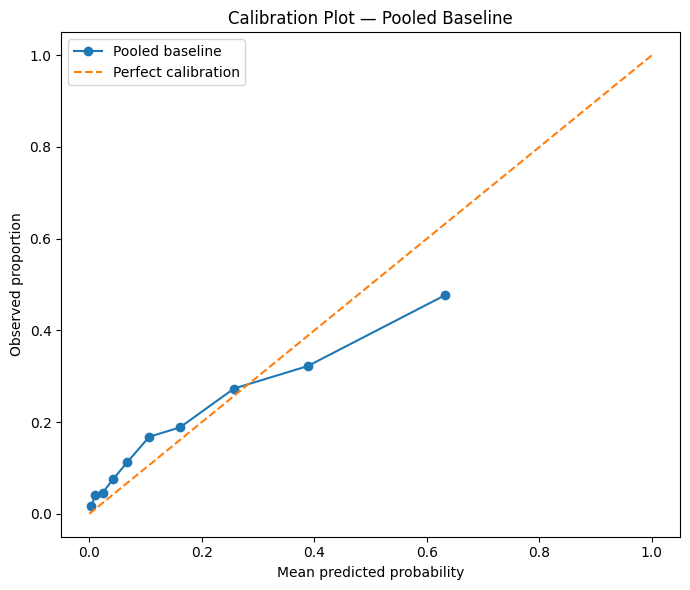

In [24]:
# Calibration plot

prob_true, prob_pred = calibration_curve(
    y_test,
    y_test_proba,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Pooled baseline"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed proportion")
plt.title("Calibration Plot — Pooled Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# Evaluate regional performance
regional_results = []

for source in ["Ghana", "Nigeria"]:
    mask = source_test == source

    y_true_source = y_test[mask]
    y_proba_source = y_test_proba[mask]
    y_pred_source = y_test_pred[mask]

    tn, fp, fn, tp = confusion_matrix(
        y_true_source,
        y_pred_source
    ).ravel()

    regional_results.append({
        "source": source,
        "n": len(y_true_source),
        "auc": roc_auc_score(y_true_source, y_proba_source),
        "sensitivity": tp / (tp + fn),
        "specificity": tn / (tn + fp),
        "ppv": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "npv": tn / (tn + fn) if (tn + fn) > 0 else 0,
        "brier": brier_score_loss(y_true_source, y_proba_source)
    })

regional_results = pd.DataFrame(regional_results)

regional_results

,source,n,auc,sensitivity,specificity,ppv,npv,brier
0,Ghana,1569,0.741842,0.099448,0.980548,0.400000,0.893045,0.098323
1,Nigeria,818,0.742487,0.386957,0.865646,0.529762,0.783077,0.179970


### 8. Hyperparameter Tuning

The pooled training set is used to tune the XGBoost model using 10-fold cross-validation. Hyperparameter selection is performed exclusively within the training data, with `scale_pos_weight` excluded so that class imbalance is handled through the subsequent decision-threshold selection.

In [26]:
# Tune the pooled XGBoost model using only the training data and 10-fold CV

# Base estimator
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1
)

# Search space
param_grid = {
    "n_estimators": [100, 200, 300, 500, 750, 1000],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "gamma": [0, 0.1, 0.3, 0.5, 1],
}

# Cross-validation strategy
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Search for the hyperparameter combination with the highest ROC-AUC
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True
)

# Fit search
random_search.fit(X_train, y_train)

# Store the best hyperparameters and cross-validated score
best_params = random_search.best_params_
best_cv_auc = random_search.best_score_

print("Best hyperparameters:")
print(best_params)
print(f"\nBest CV AUC: {best_cv_auc:.4f}")

Best hyperparameters:
{'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.5}

Best CV AUC: 0.8081


### 9. Out-of-Fold Predictions and Threshold Selection

Out-of-fold probabilities are generated within the pooled training set using the selected hyperparameters. The decision threshold is then selected using Youden's index, ensuring that threshold selection does not use the held-out test set.

In [27]:
# Generate out-of-fold probabilities and select the decision threshold using Youden's index

# Recreate the selected XGBoost model using the best hyperparameters
threshold_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
    **best_params # finally got a relevant reason to use kwargs!
)

# Generate out-of-fold predicted probabilities for the training set
y_train_oof_proba = cross_val_predict(
    threshold_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Calculate sensitivity and false-positive rate across possible thresholds
fpr, tpr, thresholds = roc_curve(
    y_train,
    y_train_oof_proba
)

# Select the threshold that maximizes Youden's index
youden_index = tpr - fpr
best_index = np.argmax(youden_index)

chosen_threshold = thresholds[best_index]

print(f"Chosen threshold: {chosen_threshold:.4f}")
print(f"Youden's index: {youden_index[best_index]:.4f}")

Chosen threshold: 0.1689
Youden's index: 0.4881


### 10. Final Tuned Model

The final XGBoost model is refitted on the complete pooled training set using the selected hyperparameters. The OOF-derived decision threshold is then fixed at 0.1689 before any evaluation on the held-out test set.

In [28]:
# Fit the final tuned XGBoost model on the complete training set

final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=1,
    **best_params
)

# Refit using all available pooled training data
final_model.fit(X_train, y_train)

# Freeze the OOF-derived decision threshold for final evaluation
final_threshold = chosen_threshold

print("Final model fitted on the complete training set.")
print(f"Final decision threshold: {final_threshold:.4f}")

Final model fitted on the complete training set.
Final decision threshold: 0.1689


### 11. Final Tuned Model Evaluation

The frozen tuned model and decision threshold are evaluated on the held-out test set. Performance is reported for the overall test set and separately by country to assess both overall performance and regional behaviour.

In [29]:
# Evaluate the frozen tuned model on the held-out test set

# Generate final test-set probabilities
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# Apply the frozen OOF-derived threshold
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# Recover country labels for the held-out test observations
test_source = pooled_model.loc[X_test.index, "source"]


def evaluate_predictions(y_true, y_proba, threshold):
    """Calculate discrimination, classification, and calibration metrics."""
    
    # Class predictions at the fixed threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Classification metrics
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    # Calibration intercept and slope
    clipped_proba = np.clip(y_proba, 1e-15, 1 - 1e-15)
    logit_proba = np.log(clipped_proba / (1 - clipped_proba))

    calibration_model = LogisticRegression(
        C=np.inf, # used an infinity value of C to drive penalty as low as possible yet, an error still shows.
        solver="lbfgs"
    )
    
    calibration_model.fit(
        logit_proba.reshape(-1, 1),
        y_true
    )

    calibration_intercept = calibration_model.intercept_[0]
    calibration_slope = calibration_model.coef_[0, 0]

    return {
        "n": len(y_true),
        "Prevalence": np.mean(y_true),
        "AUC": roc_auc_score(y_true, y_proba),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv,
        "Calibration intercept": calibration_intercept,
        "Calibration slope": calibration_slope,
        "Brier score": brier_score_loss(y_true, y_proba),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }


# Evaluate the overall held-out test set
overall_results = evaluate_predictions(
    y_test,
    y_test_proba,
    final_threshold
)

# Evaluate the Ghana-origin test subset
ghana_mask = test_source == "Ghana"

ghana_results = evaluate_predictions(
    y_test[ghana_mask],
    y_test_proba[ghana_mask],
    final_threshold
)

# Evaluate the Nigeria-origin test subset
nigeria_mask = test_source == "Nigeria"

nigeria_results = evaluate_predictions(
    y_test[nigeria_mask],
    y_test_proba[nigeria_mask],
    final_threshold
)

# Display the results side by side
final_results = pd.DataFrame(
    {
        "Overall": overall_results,
        "Ghana": ghana_results,
        "Nigeria": nigeria_results
    }
)

display(final_results.round(4))

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


,Overall,Ghana,Nigeria
n,2387.0000,1569.0000,818.0000
Prevalence,0.1722,0.1154,0.2812
AUC,0.8030,0.7677,0.7843
Sensitivity,0.7591,0.6077,0.8783
Specificity,0.6984,0.7702,0.5289
PPV,0.3436,0.2564,0.4217
NPV,0.9331,0.9377,0.9174
Calibration intercept,-0.0076,-0.2131,0.0870
Calibration slope,0.9889,0.9188,0.9748
Brier score,0.1160,0.0920,0.1619


### 12. Consolidated Performance Comparison

In [34]:
# Consolidated performance comparison across HyperSense development stages

# ------------------------------------------------------------------
# 1. Ghana v1.1 reported performance
# ------------------------------------------------------------------

ghana_v11 = {
    "AUC": 0.792,
    "Sensitivity": 0.823,
    "Specificity": 0.576,
    "PPV": 0.202,
    "NPV": 0.962,
    "Calibration intercept": np.nan,
    "Calibration slope": np.nan,
    "Brier score": 0.235
}


# ------------------------------------------------------------------
# 2. Stage 1 REMAH transportability evaluation
#    Full Nigerian REMAH cohort
# ------------------------------------------------------------------

remah_stage1 = {
    "AUC": 0.747,
    "Sensitivity": 0.941,
    "Specificity": 0.407,
    "PPV": 0.383,
    "NPV": 0.946,
    "Calibration intercept": -1.798,
    "Calibration slope": 1.276,
    "Brier score": 0.276
}


# ------------------------------------------------------------------
# 3. Stage 2 pooled baseline performance
#    Frozen baseline model evaluated on the held-out pooled test set
# ------------------------------------------------------------------

stage2_baseline = {
    "AUC": 0.772,
    "Sensitivity": 0.260,
    "Specificity": 0.946,
    "PPV": 0.502,
    "NPV": 0.860,
    "Calibration intercept": -0.423,
    "Calibration slope": 0.623,
    "Brier score": 0.126
}


# ------------------------------------------------------------------
# 4. Stage 2 final tuned model
#    Overall + Ghana + Nigeria
# ------------------------------------------------------------------

stage2_tuned_overall = {
    metric: overall_results[metric]
    for metric in [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Calibration intercept",
        "Calibration slope",
        "Brier score"
    ]
}

stage2_tuned_ghana = {
    metric: ghana_results[metric]
    for metric in [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Calibration intercept",
        "Calibration slope",
        "Brier score"
    ]
}

stage2_tuned_nigeria = {
    metric: nigeria_results[metric]
    for metric in [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Calibration intercept",
        "Calibration slope",
        "Brier score"
    ]
}


# ------------------------------------------------------------------
# 5. Construct consolidated comparison table
# ------------------------------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "AUC",
        "Sensitivity",
        "Specificity",
        "PPV",
        "NPV",
        "Calibration intercept",
        "Calibration slope",
        "Brier score"
    ],
    "Ghana v1.1 (reported)": [
        ghana_v11["AUC"],
        ghana_v11["Sensitivity"],
        ghana_v11["Specificity"],
        ghana_v11["PPV"],
        ghana_v11["NPV"],
        ghana_v11["Calibration intercept"],
        ghana_v11["Calibration slope"],
        ghana_v11["Brier score"]
    ],
    "Stage 1 REMAH (full cohort)": [
        remah_stage1["AUC"],
        remah_stage1["Sensitivity"],
        remah_stage1["Specificity"],
        remah_stage1["PPV"],
        remah_stage1["NPV"],
        remah_stage1["Calibration intercept"],
        remah_stage1["Calibration slope"],
        remah_stage1["Brier score"]
    ],
    "Stage 2 baseline": [
        stage2_baseline["AUC"],
        stage2_baseline["Sensitivity"],
        stage2_baseline["Specificity"],
        stage2_baseline["PPV"],
        stage2_baseline["NPV"],
        stage2_baseline["Calibration intercept"],
        stage2_baseline["Calibration slope"],
        stage2_baseline["Brier score"]
    ],
    "Stage 2 tuned (overall)": [
        stage2_tuned_overall["AUC"],
        stage2_tuned_overall["Sensitivity"],
        stage2_tuned_overall["Specificity"],
        stage2_tuned_overall["PPV"],
        stage2_tuned_overall["NPV"],
        stage2_tuned_overall["Calibration intercept"],
        stage2_tuned_overall["Calibration slope"],
        stage2_tuned_overall["Brier score"]
    ],
    "Stage 2 tuned (Ghana)": [
        stage2_tuned_ghana["AUC"],
        stage2_tuned_ghana["Sensitivity"],
        stage2_tuned_ghana["Specificity"],
        stage2_tuned_ghana["PPV"],
        stage2_tuned_ghana["NPV"],
        stage2_tuned_ghana["Calibration intercept"],
        stage2_tuned_ghana["Calibration slope"],
        stage2_tuned_ghana["Brier score"]
    ],
    "Stage 2 tuned (Nigeria)": [
        stage2_tuned_nigeria["AUC"],
        stage2_tuned_nigeria["Sensitivity"],
        stage2_tuned_nigeria["Specificity"],
        stage2_tuned_nigeria["PPV"],
        stage2_tuned_nigeria["NPV"],
        stage2_tuned_nigeria["Calibration intercept"],
        stage2_tuned_nigeria["Calibration slope"],
        stage2_tuned_nigeria["Brier score"]
    ]
})

display(comparison.round(4))

,Metric,Ghana v1.1 (reported),Stage 1 REMAH (full cohort),Stage 2 baseline,Stage 2 tuned (overall),Stage 2 tuned (Ghana),Stage 2 tuned (Nigeria)
0,AUC,0.792,0.747,0.772,0.8030,0.7677,0.7843
1,Sensitivity,0.823,0.941,0.260,0.7591,0.6077,0.8783
2,Specificity,0.576,0.407,0.946,0.6984,0.7702,0.5289
3,PPV,0.202,0.383,0.502,0.3436,0.2564,0.4217
4,NPV,0.962,0.946,0.860,0.9331,0.9377,0.9174
5,Calibration intercept,NaN,-1.798,-0.423,-0.0076,-0.2131,0.0870
6,Calibration slope,NaN,1.276,0.623,0.9889,0.9188,0.9748
7,Brier score,0.235,0.276,0.126,0.1160,0.0920,0.1619


###  Export Stage 2 Results for Reproducibility

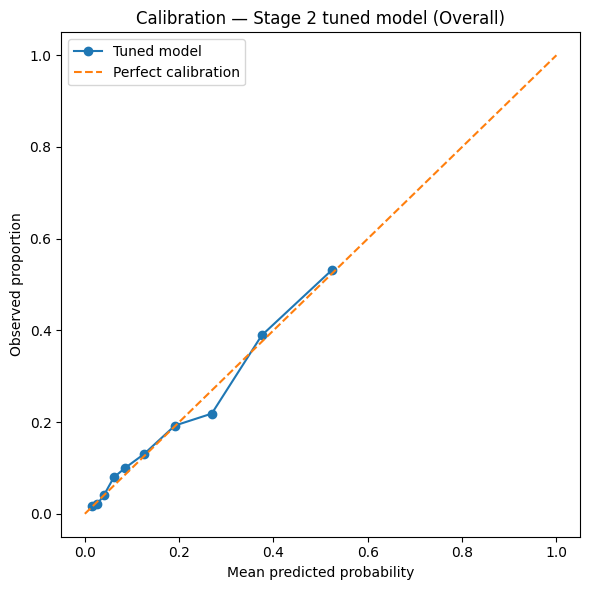

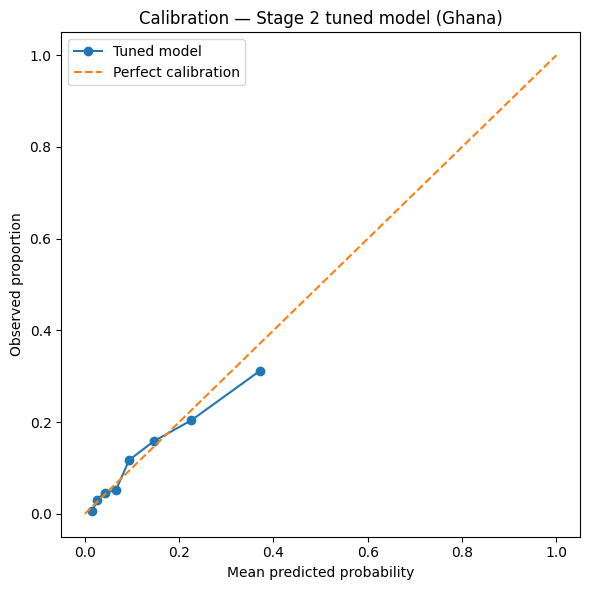

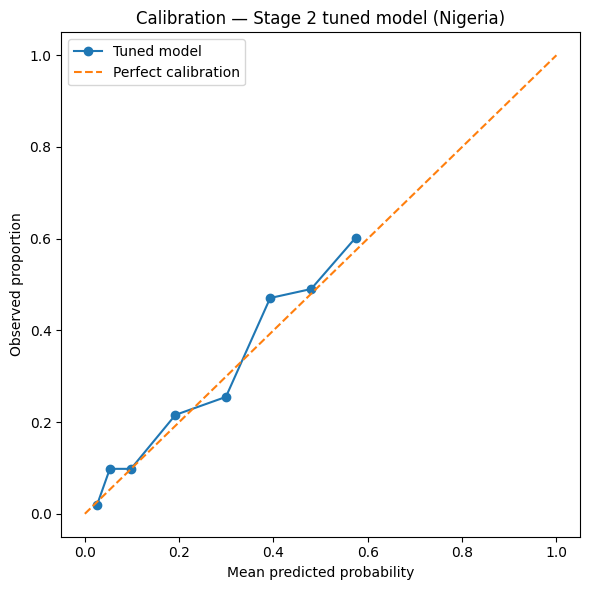

Stage 2 outputs exported successfully:
 - consolidated_performance_comparison.csv
 - stage2_calibration_ghana.png
 - stage2_calibration_nigeria.png
 - stage2_calibration_overall.png
 - stage2_model_configuration.json
 - stage2_tuned_results.csv


In [39]:
# Create dedicated output directory
output_dir = Path("../outputs/regional_adaptation")
output_dir.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------
# 1. Export consolidated performance comparison
# ---------------------------------------------------------

comparison.to_csv(
    output_dir / "consolidated_performance_comparison.csv",
    index=False
)


# ---------------------------------------------------------
# 2. Export final tuned model results
# ---------------------------------------------------------

stage2_tuned_results = final_results.copy()

stage2_tuned_results.to_csv(
    output_dir / "stage2_tuned_results.csv"
)


# ---------------------------------------------------------
# 3. Export selected modelling parameters
# ---------------------------------------------------------

model_configuration = {
    "best_hyperparameters": best_params,
    "best_cv_auc": best_cv_auc,
    "chosen_threshold": final_threshold,
    "threshold_selection_method": "Youden's index using 10-fold out-of-fold predicted probabilities",
    "final_model_training_data": "Complete pooled Ghana-Nigeria training set",
    "final_model_evaluation_data": "Held-out pooled Ghana-Nigeria test set"
}

with open(
    output_dir / "stage2_model_configuration.json",
    "w"
) as f:
    json.dump(model_configuration, f, indent=4)


# ---------------------------------------------------------
# 4. Calibration plots for the final tuned model
# ---------------------------------------------------------

calibration_sets = {
    "Overall": (y_test, y_test_proba),
    "Ghana": (
        y_test[ghana_mask],
        y_test_proba[ghana_mask]
    ),
    "Nigeria": (
        y_test[nigeria_mask],
        y_test_proba[nigeria_mask]
    )
}

for name, (y_true, y_proba) in calibration_sets.items():

    # Use fewer bins for subgroup plots because of smaller sample sizes
    n_bins = 10 if name == "Overall" else 8

    prob_true, prob_pred = calibration_curve(
        y_true,
        y_proba,
        n_bins=n_bins,
        strategy="quantile"
    )

    plt.figure(figsize=(6, 6))

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label="Tuned model"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed proportion")
    plt.title(f"Calibration — Stage 2 tuned model ({name})")
    plt.legend()
    plt.tight_layout()

    filename = (
        "stage2_calibration_overall.png"
        if name == "Overall"
        else f"stage2_calibration_{name.lower()}.png"
    )

    plt.savefig(
        output_dir / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# ---------------------------------------------------------
# 5. Confirm exported files
# ---------------------------------------------------------

print("Stage 2 outputs exported successfully:")
for file in sorted(output_dir.iterdir()):
    print(f" - {file.name}")

### Stage 2 Conclusion

Stage 2 evaluated whether incorporating harmonized Nigerian data into the development process could improve the performance of the Ghana-derived HyperSense model in a pooled Ghanaian–Nigerian population. The pooled baseline model demonstrated reasonable discrimination (AUC = 0.772) but poor sensitivity at the default 0.50 decision threshold (0.260), despite high specificity (0.946). This highlighted the inadequacy of retaining the default classification threshold for a screening-oriented application.

**Hyperparameter tuning** was therefore performed exclusively within the pooled training data using 10-fold cross-validation, followed by leakage-free threshold selection using **out-of-fold predictions**. The resulting model used a decision threshold of *0.1689*. On the previously held-out test set, the tuned model improved overall discrimination from an AUC of 0.772 to 0.803 and substantially increased sensitivity from 0.260 to 0.759, while reducing specificity from 0.946 to 0.698. This represents the expected sensitivity–specificity trade-off associated with lowering the classification threshold, but is more appropriate for the intended screening context. The tuned model also produced a lower Brier score (0.116 vs. 0.126) and substantially improved calibration, with an overall calibration intercept of −0.008 and calibration slope of 0.989, compared with −0.423 and 0.623 for the pooled baseline model.

Importantly, the country-specific evaluation showed that the tuned model retained similar discrimination in both populations, with AUCs of 0.768 in Ghana and 0.784 in Nigeria. In the Nigerian subset, sensitivity increased to 0.878 while specificity was 0.529, with a calibration intercept of 0.087 and calibration slope of 0.975. Compared with the Stage 1 transportability evaluation in the full REMAH cohort (AUC = 0.747, sensitivity = 0.941, specificity = 0.407, calibration intercept = −1.798, calibration slope = 1.276), the adapted model demonstrates improved discrimination and substantially better calibration, while achieving a more balanced sensitivity–specificity profile.

Overall, these findings support the utility of regional adaptation: allowing Nigerian observations to contribute to model development produced a model with stronger overall discrimination, substantially improved calibration, and improved balance between sensitivity and specificity relative to the unadapted and pooled baseline approaches. It should be noted that hyperparameter tuning and threshold re-derivation were introduced concurrently with the inclusion of Nigerian training data, so this comparison does not by itself isolate the contribution of the additional Nigerian observations from the effect of moving to a properly tuned model and threshold — a distinction v1.1 was never evaluated under. Disentangling these two effects (e.g., via a Ghana-only model taken through an identical tuning and threshold-selection pipeline) is left as a direction for further exploration.